**Étape 1 – Préparation**

Vérifier le GPU

In [ ]:
import tensorflow as tf

print("Version TensorFlow :", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU détecté :", gpus if gpus else "AUCUN ⚠️ -> active le GPU dans Exécution > Modifier le type d'exécution")

Version TensorFlow : 2.20.0
GPU détecté : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, zipfile, glob

ZIP_PATH = '/content/drive/MyDrive/projet_palm/Diseases of date palm leaves dataset.zip'
DATA_ROOT = '/content/data'

#  Dézipper l'archive principale
os.makedirs(DATA_ROOT, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_ROOT)

print("✅ Décompression terminée")

✅ Décompression terminée


Explorer la structure des dossiers

In [ ]:
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

def arborescence(path, niveau=0, max_niveau=4):
    """Affiche les dossiers et le nombre d'images dans chacun."""
    if niveau > max_niveau:
        return
    for nom in sorted(os.listdir(path)):
        chemin = os.path.join(path, nom)
        if os.path.isdir(chemin):
            nb_images = len([f for f in os.listdir(chemin) if f.lower().endswith(IMG_EXT)])
            print("    " * niveau + f"📁 {nom}  ({nb_images} images)")
            arborescence(chemin, niveau + 1, max_niveau)

arborescence(DATA_ROOT)

📁 Diseases of date palm leaves dataset  (0 images)
    📁 Infected Date Palm Leaves Dataset  (0 images)
        📁 Processed  (0 images)
            📁 1. Potassium Deficiency  (831 images)
            📁 2. Manganese Deficiency  (415 images)
            📁 3. Magnesium Deficiency  (566 images)
            📁 4. Black Scorch  (106 images)
            📁 5. Leaf Spots  (69 images)
            📁 6. Fusarium Wilt  (210 images)
            📁 7. Rachis Blight  (402 images)
            📁 8. Parlatoria Blanchardi  (101 images)
            📁 9. Healthy sample  (389 images)
        📁 Raw  (0 images)
            📁 1. Potassium Deficiency  (58 images)
            📁 2. Manganese Deficiency  (0 images)
            📁 3. Magnesium Deficiency  (22 images)
            📁 4. Black Scorch  (49 images)
            📁 5. Leaf Spots  (28 images)
            📁 6. Fusarium Wilt  (62 images)
            📁 7. Rachis Blight  (69 images)
            📁 8. Parlatoria Blanchardi  (21 images)
            📁 9. Healthy sample  

In [ ]:
import random, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✅ Imports OK, graine fixée à", SEED)

✅ Imports OK, graine fixée à 42


In [ ]:
def compte_images(chemin_dossier):
    """Compte le nombre d'images dans un dossier."""
    return len([f for f in os.listdir(chemin_dossier) if f.lower().endswith(IMG_EXT)])

DATA_DIR = os.path.join(DATA_ROOT, 'Diseases of date palm leaves dataset', 'Infected Date Palm Leaves Dataset', 'Raw')
CLASSES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASSES)

print("Dossier utilisé :", DATA_DIR)
print("Nombre de classes :", NUM_CLASSES)
for i, c in enumerate(CLASSES):
    print(f"  {i} → {c}  ({compte_images(os.path.join(DATA_DIR, c))} images)")

Dossier utilisé : /content/data/Diseases of date palm leaves dataset/Infected Date Palm Leaves Dataset/Raw
Nombre de classes : 9
  0 → 1. Potassium Deficiency  (58 images)
  1 → 2. Manganese Deficiency  (0 images)
  2 → 3. Magnesium Deficiency  (22 images)
  3 → 4. Black Scorch  (49 images)
  4 → 5. Leaf Spots  (28 images)
  5 → 6. Fusarium Wilt  (62 images)
  6 → 7. Rachis Blight  (69 images)
  7 → 8. Parlatoria Blanchardi  (21 images)
  8 → 9. Healthy sample  (27 images)


In [ ]:
from collections import Counter

inventaire = {}
for c in CLASSES:
    exts = Counter(os.path.splitext(f)[1].lower() for f in os.listdir(os.path.join(DATA_DIR, c)))
    inventaire[c] = dict(exts)

pd.DataFrame(inventaire).T.fillna(0).astype(int)

,.jpg,.jpeg,.heic,.2,.1,.jfif,.png
1. Potassium Deficiency,47,11,29,1,1,0,0
2. Manganese Deficiency,0,0,9,0,0,7,0
3. Magnesium Deficiency,22,0,17,3,13,0,0
4. Black Scorch,45,3,21,1,1,10,1
5. Leaf Spots,15,13,34,1,5,0,0
6. Fusarium Wilt,48,14,21,1,7,11,0
7. Rachis Blight,32,29,31,0,0,0,8
8. Parlatoria Blanchardi,21,0,27,0,0,12,0
9. Healthy sample,19,0,9,0,0,0,8


In [ ]:
!pip install -q pillow-heif
from pillow_heif import register_heif_opener
from PIL import ImageOps
register_heif_opener()                      # apprend à PIL à lire le format HEIC

A_CONVERTIR = ('.heic', '.heif', '.jfif', '.webp')
convertis, echecs = 0, []

for c in CLASSES:
    dossier = os.path.join(DATA_DIR, c)
    for f in os.listdir(dossier):
        base, ext = os.path.splitext(f)
        if ext.lower() not in A_CONVERTIR:
            continue
        src = os.path.join(dossier, f)
        dst = os.path.join(dossier, base + '.jpg')
        if os.path.exists(dst):                          # évite d'écraser une image existante
            dst = os.path.join(dossier, f"{base}_{ext[1:].lower()}.jpg")
        try:
            with Image.open(src) as img:
                img = ImageOps.exif_transpose(img)       # remet la photo dans le bon sens
                img.convert('RGB').save(dst, 'JPEG', quality=95)
            os.remove(src)
            convertis += 1
        except Exception as e:
            echecs.append((src, str(e)))

print(f"✅ {convertis} image(s) convertie(s) en JPG")
print(f"❌ {len(echecs)} échec(s)")
for src, err in echecs:
    print("   ", src, "→", err)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 64.5 MB/s eta 0:00:00
✅ 238 image(s) convertie(s) en JPG
❌ 0 échec(s)


**Distribution des classes et mesure du déséquilibre**

2. Manganese Deficiency      16
9. Healthy sample            36
3. Magnesium Deficiency      39
8. Parlatoria Blanchardi     60
5. Leaf Spots                62
4. Black Scorch              80
1. Potassium Deficiency      87
6. Fusarium Wilt             94
7. Rachis Blight            100

Total : 574 images
Moyenne : 64 images par classe
Ratio déséquilibre (max/min) : 6.2


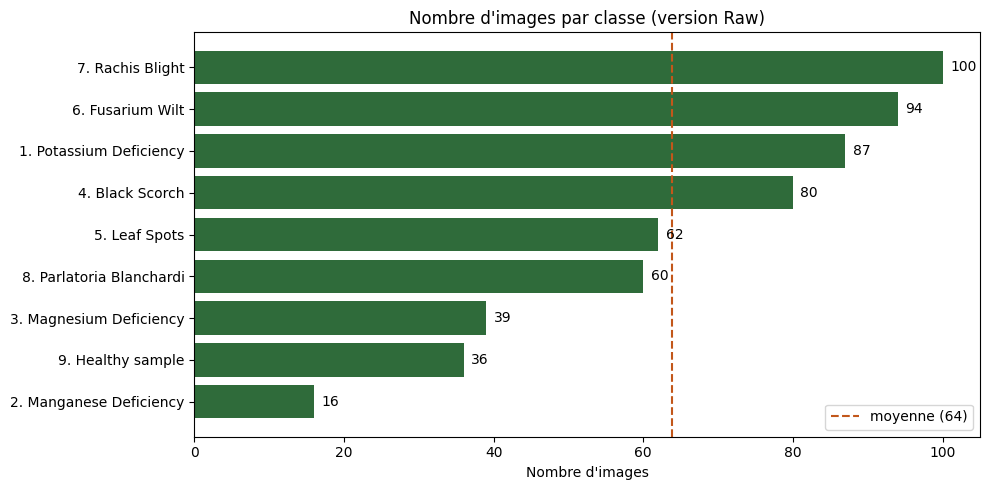

In [ ]:
comptes = pd.Series({c: compte_images(os.path.join(DATA_DIR, c)) for c in CLASSES}).sort_values()

print(comptes.to_string())
print(f"\nTotal : {comptes.sum()} images")
print(f"Moyenne : {comptes.mean():.0f} images par classe")
print(f"Ratio déséquilibre (max/min) : {comptes.max() / comptes.min():.1f}")

plt.figure(figsize=(10, 5))
barres = plt.barh(comptes.index, comptes.values, color='#2f6b3a')
plt.axvline(comptes.mean(), color='#c2571a', linestyle='--', label=f"moyenne ({comptes.mean():.0f})")
for barre, v in zip(barres, comptes.values):
    plt.text(v + 1, barre.get_y() + barre.get_height() / 2, str(v), va='center')
plt.title("Nombre d'images par classe (version Raw)")
plt.xlabel("Nombre d'images")
plt.legend()
plt.tight_layout()
plt.savefig('/content/distribution_classes.png', dpi=150)   # figure pour le rapport
plt.show()

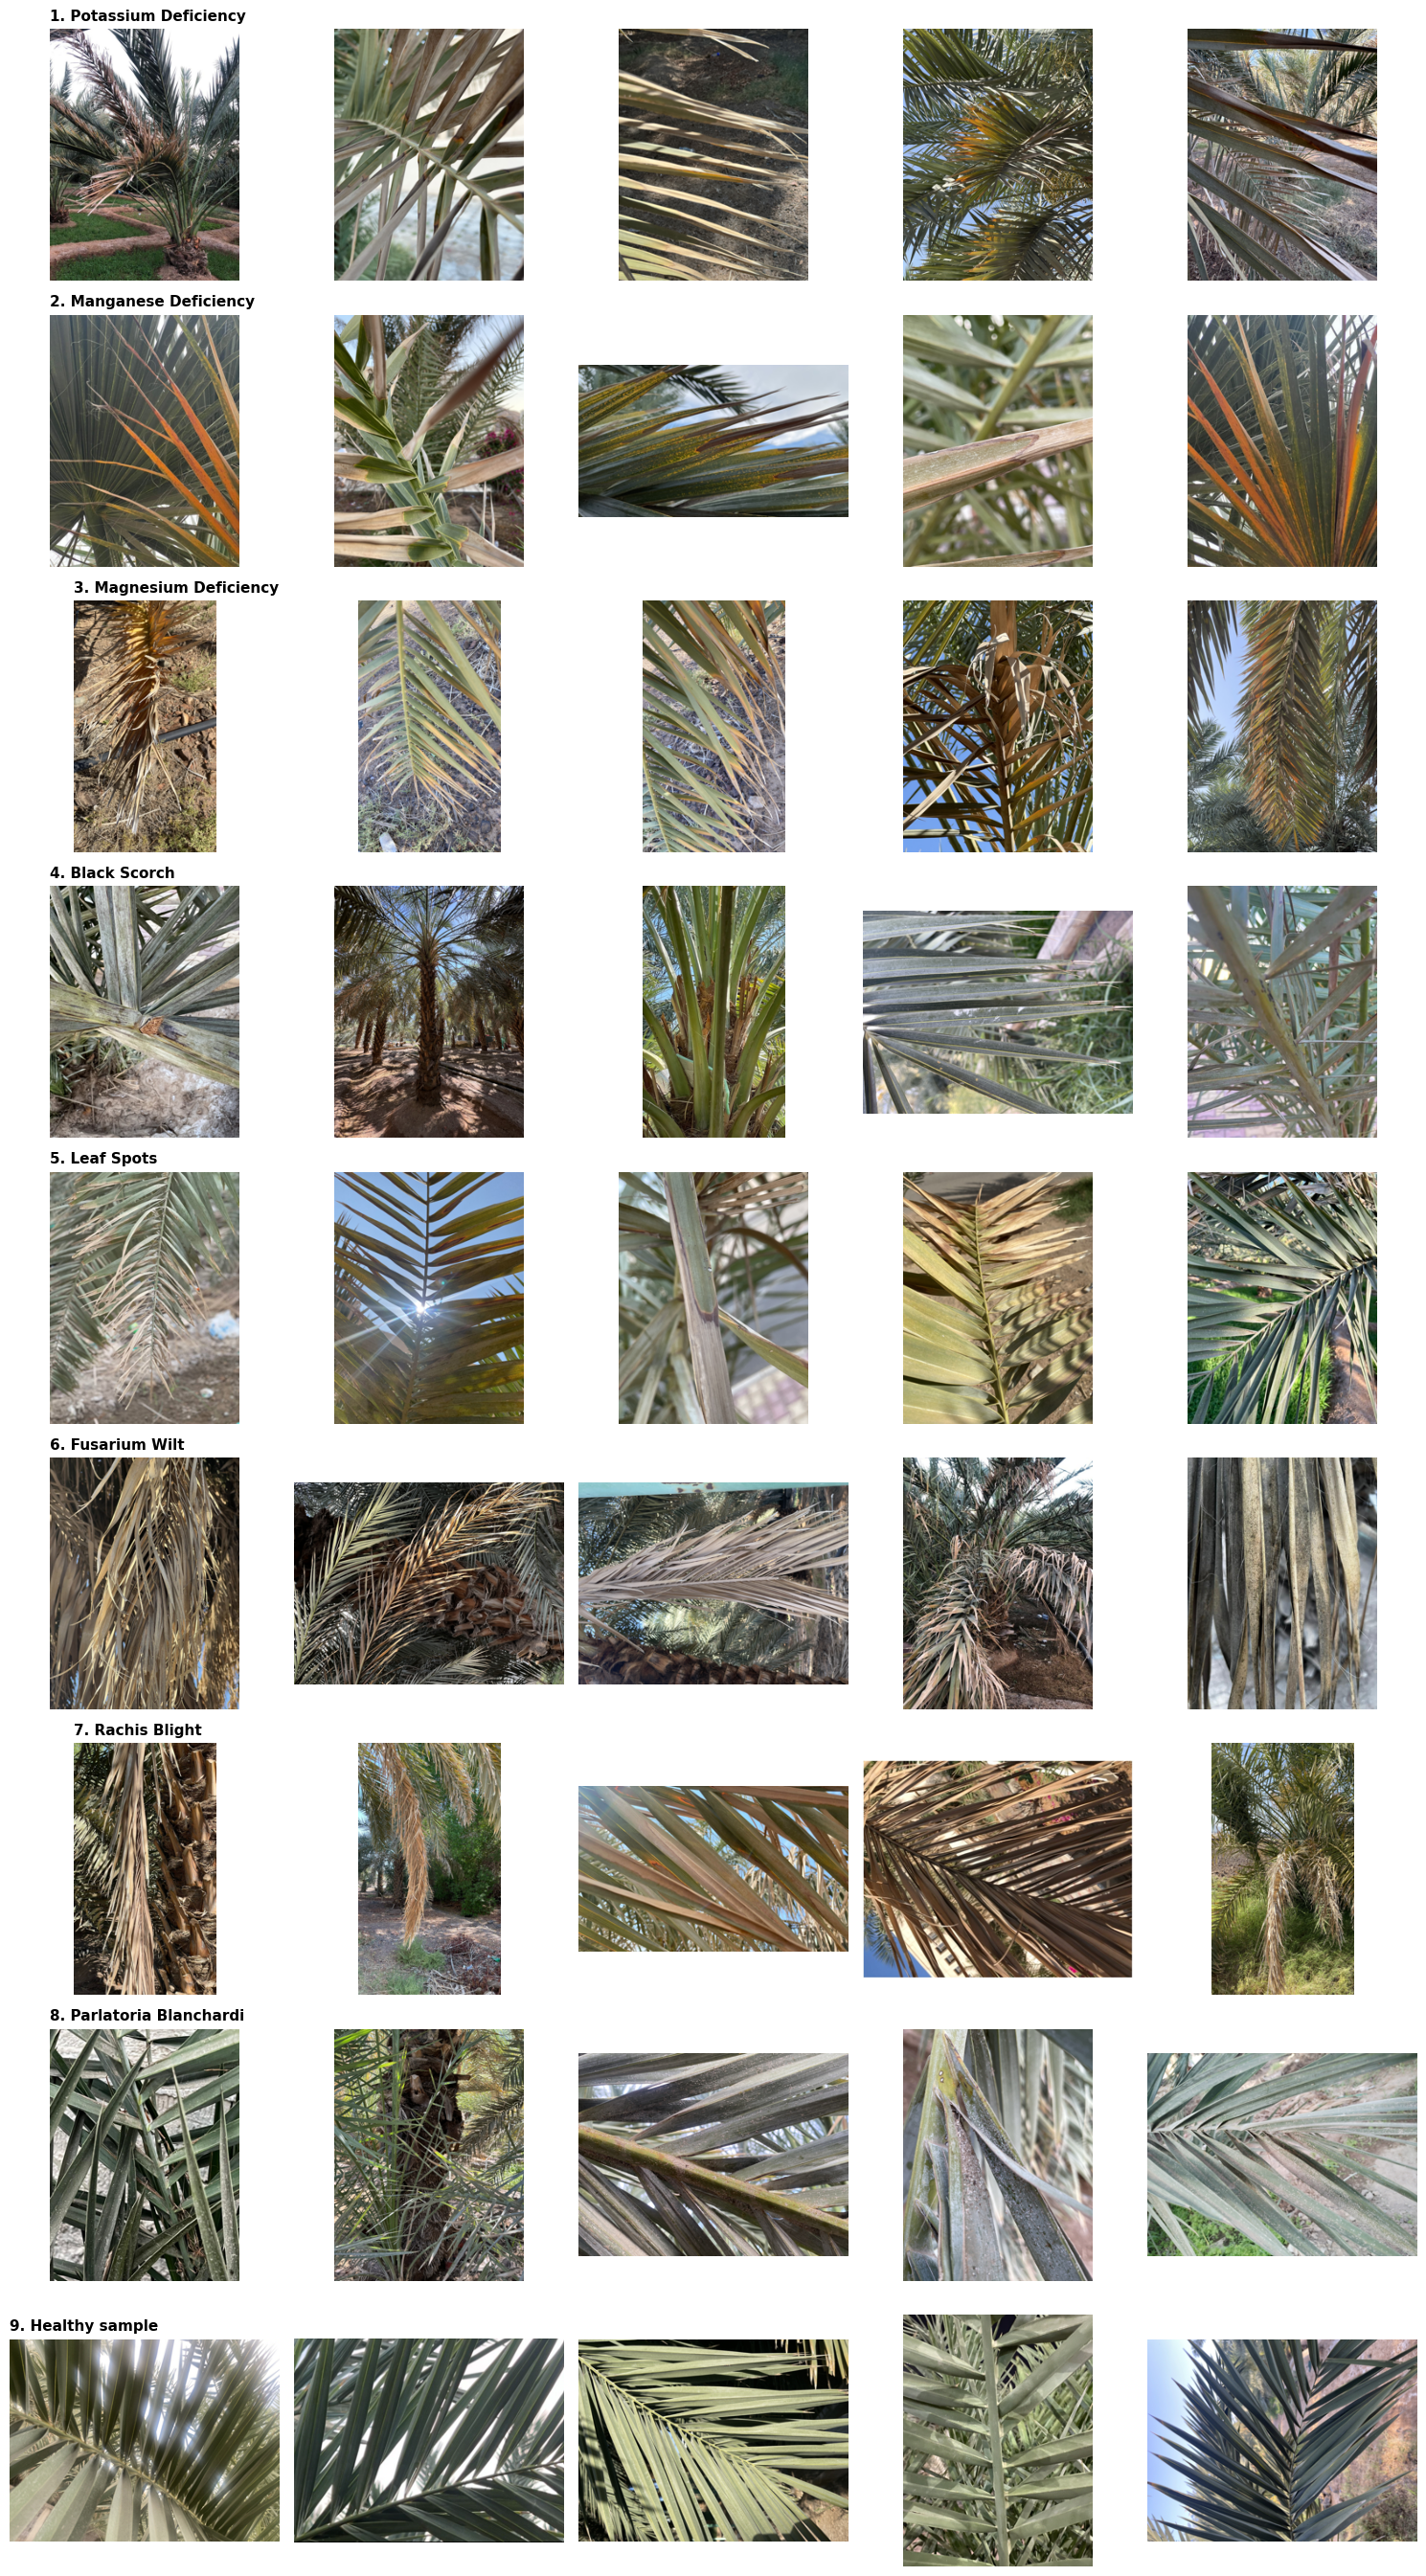

In [ ]:
N_EXEMPLES = 5
fig, axes = plt.subplots(NUM_CLASSES, N_EXEMPLES, figsize=(3 * N_EXEMPLES, 3 * NUM_CLASSES))

for i, c in enumerate(CLASSES):
    dossier = os.path.join(DATA_DIR, c)
    fichiers = [f for f in os.listdir(dossier) if f.lower().endswith(IMG_EXT)]
    choix = random.sample(fichiers, min(N_EXEMPLES, len(fichiers)))
    for j in range(N_EXEMPLES):
        ax = axes[i, j]
        ax.axis('off')
        if j < len(choix):
            with Image.open(os.path.join(dossier, choix[j])) as img:
                img.thumbnail((300, 300))          # miniature : affichage rapide, peu de mémoire
                ax.imshow(img.convert('RGB'))
    axes[i, 0].set_title(c, loc='left', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/exemples_classes.png', dpi=120)
plt.show()

📐 Dimensions (en pixels) :
      largeur  hauteur  megapixels  ratio
min     397.0    355.0         0.2    0.4
mean   2230.8   2843.9         7.8    0.8
max    4284.0   5712.0        24.5    2.1

🎨 Modes de couleur : {'RGB': 557, 'RGBA': 17}

🔄 Orientation EXIF (1 = normale, autre = photo à pivoter) :
{1: 534, 6: 40}

Images à pivoter, par classe :
classe
1. Potassium Deficiency     2
4. Black Scorch             5
5. Leaf Spots               1
6. Fusarium Wilt           16
9. Healthy sample          16


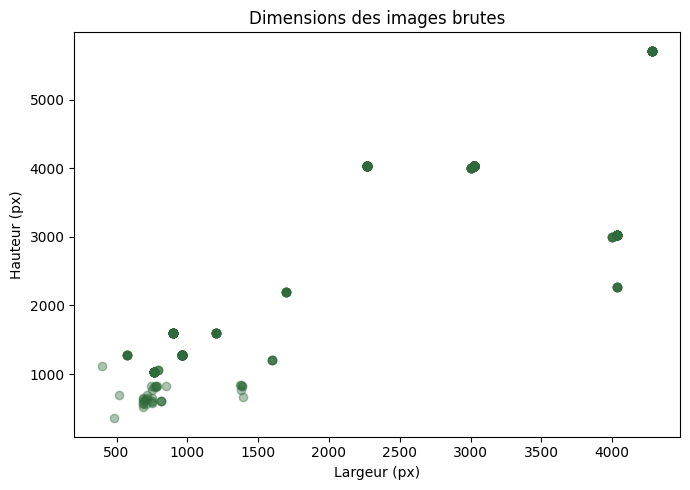

In [ ]:
lignes = []
for c in CLASSES:
    dossier = os.path.join(DATA_DIR, c)
    for f in os.listdir(dossier):
        if not f.lower().endswith(IMG_EXT):
            continue
        with Image.open(os.path.join(dossier, f)) as img:
            orientation = img.getexif().get(274, 1)
            lignes.append({
                'classe': c,
                'largeur': img.width,
                'hauteur': img.height,
                'mode': img.mode,
                'orientation_exif': orientation,
            })

df_img = pd.DataFrame(lignes)
df_img['ratio'] = (df_img['largeur'] / df_img['hauteur']).round(2)
df_img['megapixels'] = (df_img['largeur'] * df_img['hauteur'] / 1e6).round(1)

print("📐 Dimensions (en pixels) :")
print(df_img[['largeur', 'hauteur', 'megapixels', 'ratio']].describe().loc[['min', 'mean', 'max']].round(1))

print("\n🎨 Modes de couleur :", df_img['mode'].value_counts().to_dict())

print("\n🔄 Orientation EXIF (1 = normale, autre = photo à pivoter) :")
print(df_img['orientation_exif'].value_counts().to_dict())
print("\nImages à pivoter, par classe :")
print(df_img[df_img['orientation_exif'] != 1].groupby('classe').size().to_string() or "aucune ✅")

plt.figure(figsize=(7, 5))
plt.scatter(df_img['largeur'], df_img['hauteur'], alpha=0.4, color='#2f6b3a')
plt.xlabel("Largeur (px)"); plt.ylabel("Hauteur (px)")
plt.title("Dimensions des images brutes")
plt.tight_layout()
plt.savefig('/content/dimensions_images.png', dpi=120)
plt.show()

**Détecter les images corrompues**


In [ ]:
corrompues = []
for c in CLASSES:
    dossier = os.path.join(DATA_DIR, c)
    for f in os.listdir(dossier):
        if not f.lower().endswith(IMG_EXT):
            continue
        chemin = os.path.join(dossier, f)
        try:
            with Image.open(chemin) as img:
                img.verify()                 # vérifie la structure du fichier
            with Image.open(chemin) as img:
                img.load()                   # décode vraiment tous les pixels
        except Exception as e:
            corrompues.append((chemin, str(e)))

print(f"Images corrompues : {len(corrompues)}")
for chemin, err in corrompues:
    print("  ✘", os.path.relpath(chemin, DATA_DIR), "→", err)

Images corrompues : 0


**Détecter les doublons**

In [ ]:
hash_vers_fichiers = defaultdict(list)
for c in CLASSES:
    dossier = os.path.join(DATA_DIR, c)
    for f in os.listdir(dossier):
        if f.lower().endswith(IMG_EXT):
            with open(os.path.join(dossier, f), 'rb') as fh:
                h = hashlib.md5(fh.read()).hexdigest()
            hash_vers_fichiers[h].append(f"{c}/{f}")

doublons = {h: fs for h, fs in hash_vers_fichiers.items() if len(fs) > 1}
print(f"Groupes de doublons exacts : {len(doublons)}")
for fs in doublons.values():
    classes_groupe = {f.split('/')[0] for f in fs}
    alerte = "  ⚠️ CLASSES DIFFÉRENTES" if len(classes_groupe) > 1 else ""
    print("  ", fs, alerte)

Groupes de doublons exacts : 15
   ['1. Potassium Deficiency/2.2.jpg', '3. Magnesium Deficiency/16.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['2. Manganese Deficiency/8.2.jpg', '6. Fusarium Wilt/10.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/25.1.jpg', '7. Rachis Blight/10.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/28.1.jpg', '7. Rachis Blight/12.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/31.1.jpg', '6. Fusarium Wilt/41.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/30.2.jpg', '6. Fusarium Wilt/42.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/27.1.jpg', '7. Rachis Blight/11.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/29.1.jpg', '6. Fusarium Wilt/40.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['3. Magnesium Deficiency/26.1.jpg', '6. Fusarium Wilt/39.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['4. Black Scorch/32.1.jpg', '8. Parlatoria Blanchardi/23.1.jpg']   ⚠️ CLASSES DIFFÉRENTES
   ['5. Leaf Spots/28.1

**les quasi doublons**

In [ ]:
!pip install -q imagehash
import imagehash

SEUIL = 5      # distance max entre deux empreintes pour dire "quasi identiques"

empreintes = []
for c in CLASSES:
    dossier = os.path.join(DATA_DIR, c)
    for f in os.listdir(dossier):
        if f.lower().endswith(IMG_EXT):
            with Image.open(os.path.join(dossier, f)) as img:
                empreintes.append((f"{c}/{f}", imagehash.phash(img)))

quasi = []
for i in range(len(empreintes)):
    for j in range(i + 1, len(empreintes)):
        d = empreintes[i][1] - empreintes[j][1]
        if d <= SEUIL:
            quasi.append((empreintes[i][0], empreintes[j][0], d))

print(f"Paires de quasi-doublons (distance ≤ {SEUIL}) : {len(quasi)}")
for a, b, d in quasi[:15]:
    print(f"   distance {d} : {a}  ↔  {b}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.2 MB/s eta 0:00:00
Paires de quasi-doublons (distance ≤ 5) : 19
   distance 0 : 1. Potassium Deficiency/52.1.jpg  ↔  7. Rachis Blight/39.1.jpg
   distance 0 : 1. Potassium Deficiency/2.2.jpg  ↔  3. Magnesium Deficiency/16.1.jpg
   distance 0 : 1. Potassium Deficiency/53.1.jpg  ↔  7. Rachis Blight/38.1.jpg
   distance 0 : 1. Potassium Deficiency/51.1.jpg  ↔  7. Rachis Blight/40.1.jpg
   distance 0 : 2. Manganese Deficiency/8.2.jpg  ↔  6. Fusarium Wilt/10.1.jpg
   distance 0 : 3. Magnesium Deficiency/25.1.jpg  ↔  7. Rachis Blight/10.1.jpg
   distance 0 : 3. Magnesium Deficiency/28.1.jpg  ↔  7. Rachis Blight/12.1.jpg
   distance 0 : 3. Magnesium Deficiency/31.1.jpg  ↔  6. Fusarium Wilt/41.1.jpg
   distance 0 : 3. Magnesium Deficiency/30.2.jpg  ↔  6. Fusarium Wilt/42.1.jpg
   distance 0 : 3. Magnesium Deficiency/27.1.jpg  ↔  7. Rachis Blight/11.1.jpg
   distance 0 : 3. Magnesium Deficiency/29.1.jpg  ↔  6. Fusarium Wilt/40.1.jpg
 